# Jupyter - Lecture 7
# Even More Linear Regression

In the last few lectures, we have focused on linear regression, that is, fitting models of the form 

$$
Y =  \beta_0 +  \beta_1 X_1 +  \beta_2 X_2 + \cdots +  \beta_pX_p + \varepsilon
$$

In this lab, we will continue to use two different tools for linear regression. 
- [Scikit learn](https://scikit-learn.org/stable/index.html) is arguably the most used tool for machine learning in python 
- [Statsmodels](https://www.statsmodels.org) provides many of the statisitcial tests we've been learning in class

This lab will cover two ideas: 
- Categorical variables and how to represent them as dummy variables. 
- How to build interaction terms and pass them into your favorite model.

In [1]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import statsmodels.formula.api as smf

## More questions to ask of your model (Continued from last time)

### Q3: How well does the model fit?

This section talks about interpretation of $R^2$ and RSE, but is on slides only. 

### Q4: Making predictions



In [2]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/27085b33898cca7fb57dc6897c2deccd/Advertising.csv"
advertising_df = pd.read_csv(url, index_col = 0)
# I need to sort the rows by TV to make plotting work better later 
advertising_df= advertising_df.sort_values(by=['TV'])
advertising_df.head()

,TV,Radio,Newspaper,Sales
131,0.7,39.6,8.7,1.6
156,4.1,11.6,5.7,3.2
79,5.4,29.9,9.4,5.3
57,7.3,28.1,41.4,5.5
127,7.8,38.9,50.6,6.6


In [4]:
# I want to just learn Sales using TV
est = smf.ols('Sales ~ TV', advertising_df).fit()
est.params

Intercept    7.032594
TV           0.047537
dtype: float64

In [5]:
# Here is a table giving us the CI and PI information 
alpha = 0.1
# alpha = 0.05
# alpha = 0.01
# alpha = 0.001
advert_summary = est.get_prediction(advertising_df).summary_frame(alpha=alpha)
advert_summary.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,7.065869,0.456216,6.311932,7.819806,1.628140,12.503598
1,7.227494,0.448345,6.486566,7.968422,1.791553,12.663435
2,7.289291,0.445348,6.553316,8.025267,1.854023,12.724559
3,7.379611,0.440981,6.650852,8.108370,1.945316,12.813907
4,7.403379,0.439835,6.676515,8.130244,1.969338,12.837421


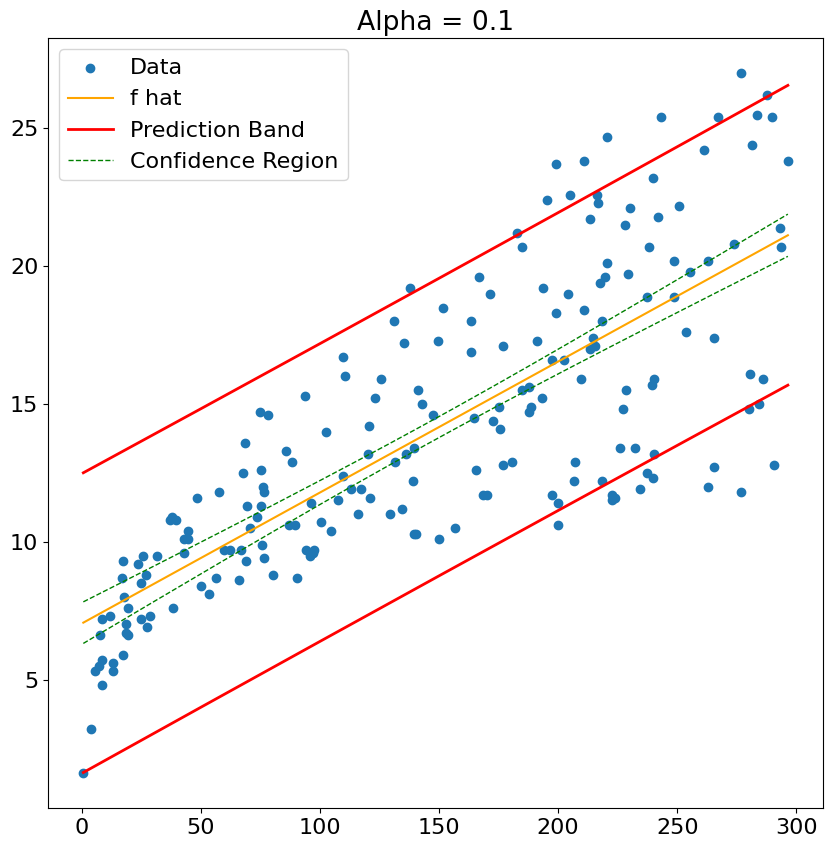

In [6]:
# And here is some code that will draw these beasts for us....
plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams['font.size'] = 16


x = advertising_df['TV']
y = advertising_df['Sales']


# Plot the original data 
plt.scatter(x,y, label = 'Data')

# Plot the fitted values, AKA f_hat
# you can get this in two different places, same answer
# plt.plot(x,advert_summary['mean'], color = 'orange', label = 'f hat')
plt.plot(x,est.fittedvalues, color = 'orange', label = 'f hat')



plt.plot(x,advert_summary['obs_ci_lower'], 'r', lw=2, 
         label = r'Prediction Band')
plt.plot(x,advert_summary['obs_ci_upper'], 'r', lw=2)

plt.plot(x, advert_summary['mean_ci_lower'],'g--', lw=1, 
         label = r'Confidence Region')
plt.plot(x, advert_summary['mean_ci_upper'], 'g--', lw=1)

plt.title('Alpha = '+ str(alpha))



plt.legend()

## Playing with multi-level variables 



### The wrong way

Ok, we're going to do this incorrectly to start. You pull in the `Auto` data set. You were so proud of yourself for remembering to fix the problems with the `horsepower` column that you conveniently forgot that the column with information about country of origin (`origin`) has a bunch of integers in it, representing:
- 1: `American`
- 2: `European`
- 3: `Japanese`.

In [9]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/d75c3811a83a66f8c261e5b599ef9e44/Auto.csv"
Auto_df = pd.read_csv(url)
Auto_df = Auto_df.replace('?', np.nan)
Auto_df = Auto_df.dropna()
Auto_df.horsepower = Auto_df.horsepower.astype('int')


Auto_df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

You then go on your merry way building the model 
$$
\texttt{mpg} = \beta_0 + \beta_1 \cdot \texttt{origin}. 
$$

In [10]:
from sklearn.linear_model import LinearRegression

X = Auto_df.origin.values
X = X.reshape(-1, 1)
y = Auto_df.mpg.values

regr = LinearRegression()

regr.fit(X,y)

print('beta_1 = ', regr.coef_[0])
print('beta_0 = ', regr.intercept_)

beta_1 =  5.476547480191448
beta_0 =  14.81197361541246


&#9989; **<font color=red>Q:</font>** What does your model predict for each of the three types of cars? 

In [12]:
X = Auto_df.origin.values.reshape(-1, 1)
y = Auto_df.mpg.values

regr = LinearRegression()
regr.fit(X, y)

origins = np.array([1, 2, 3]).reshape(-1, 1)
predictions = regr.predict(origins)

labels = ["American", "European", "Japanese"]

for label, pred in zip(labels, predictions):
    print(f"{label}: {pred:.2f}")

American: 20.29
European: 25.77
Japanese: 31.24


&#9989; **<font color=red>Q:</font>** Is it possible for your model to predict that both American and Japanese cars have `mpg` below European cars? 

No, impossible with this model

### The right way

Ok, so you figure out your problem and decide to load in your data and fix the `origin` column to have names as entries.

In [13]:
convertOrigin= {1: 'American', 2:'European', 3:'Japanese'}

# This command swaps out each number n for convertOrigin[n], making it one of
# the three strings instead of an integer now.
Auto_df.origin = Auto_df.origin.apply(lambda n: convertOrigin[n])
Auto_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,American,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,American,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,American,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,American,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,American,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,American,ford mustang gl
393,44.0,4,97.0,52,2130,24.6,82,European,vw pickup
394,32.0,4,135.0,84,2295,11.6,82,American,dodge rampage
395,28.0,4,120.0,79,2625,18.6,82,American,ford ranger


Below is a quick code that automatically generates our dummy variables. Yay for not having to code that mess ourselves!

In [14]:
origin_dummies_df = pd.get_dummies(Auto_df.origin, prefix='origin')
origin_dummies_df

,origin_American,origin_European,origin_Japanese
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
392,True,False,False
393,False,True,False
394,True,False,False
395,True,False,False




&#9989; **<font color=red>Q:</font>** What is the interpretation of each column in the `origin_dummies_df` data frame?

*origin_American: Takes the value 1 if the car is American, and 0 otherwise. origin_European: Takes the value 1 if the car is European, and 0 otherwise. origin_Japanese: Takes the value 1 if the car is Japanese, and 0 otherwise.*

I pass these new dummy variables into my `scikit-learn` linear regression model and get the following coefficients

In [15]:
X = origin_dummies_df.values
y = Auto_df.mpg

regr = LinearRegression()

regr.fit(X,y)

print('Coefs = ', regr.coef_)
print('Intercept = ', regr.intercept_)

Coefs =  [-5.9955451   1.57392668  4.42161842]
Intercept =  26.0290144918727


&#9989; **<font color=red>Q:</font>** Now what does your model predict for each of the three types of cars? 

In [16]:
coefs = regr.coef_
intercept = regr.intercept_

X_pred = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

mpg_pred = regr.predict(X_pred)

labels = ["American", "European", "Japanese"]

for label, mpg in zip(labels, mpg_pred):
    print(f"{label}: {mpg:.2f}")

American: 20.03
European: 27.60
Japanese: 30.45


#### Ooops

&#9989; **<font color=red>Q:</font>** Aw man, I didn't quite do what we said for the dummy variables in class. We talked about having only two dummy variables for a three level variable. Copy my code below here and fix it to have two variables instead of three. 
- Are your coefficients different now?
- Are your predictions for each of the three origins different now? 
- Does it matter which two levels you used for your dummy variables? 

In [17]:
origin_dummies_df = pd.get_dummies(Auto_df.origin, prefix='origin', drop_first=True)
origin_dummies_df.head()
X = origin_dummies_df.values
y = Auto_df.mpg.values
regr = LinearRegression()
regr.fit(X, y)
print("Coefficients:", regr.coef_)
print("Intercept:", regr.intercept_)


Coefficients: [ 7.56947179 10.41716352]
Intercept: 20.0334693877551


In [19]:
##Coefficients are different. Predictions do not change. Dummy variable choice affects interpretation, not fitted values.###

##ANSWER##
Coefficients are different (in particular, there's a different number of
them) but the prediction ends up the same.....

### Another right way

Ok, fine, I'll cave, I made you do it the hard way but you got to see how the innards worked, so maybe it's not all bad ;) 

First off, we can force `sklearn` to drop the first variable, so you don't have to do it manually every time. But you do need to know how to interpret the outputs!

In [20]:
# Even easier right way.... Note the only difference is the drop_first=True
origin_dummies_df = pd.get_dummies(Auto_df.origin, prefix='origin',drop_first=True)
print(origin_dummies_df.head())

y = Auto_df.mpg
regr = LinearRegression()
regr.fit(X,y)

   origin_European  origin_Japanese
0            False            False
1            False            False
2            False            False
3            False            False
4            False            False


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In `statsmodels`, it can automatically split up the categorical variables in a data frame, so it does the hard work for you. Note that here I'm plugging in the original `Auto_df` data frame, no processing of the categorical variables on my end at all. 

In [21]:
est = smf.ols('mpg ~ origin', Auto_df).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,20.0335,0.409,49.025,0.000,19.230,20.837
origin[T.European],7.5695,0.877,8.634,0.000,5.846,9.293
origin[T.Japanese],10.4172,0.828,12.588,0.000,8.790,12.044


&#9989; **<font color=red>Q:</font>** What is the model learned from the above printout? Be specific in terms of your dummy variables. 

In [22]:
##Intercept = reference category mean. Each dummy coefficient = difference from reference. Predictions for all categories are consistent, but coefficients meaning depends on which category is reference###



-----
### Congratulations, we're done!

Initially created by Dr. Liz Munch, modified by Dr.Lianzhang Bao and Dr. Firas Khasawneh,  Michigan State University
<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.